# Toy test predictions for trained plant disease models

This notebook loads the saved Custom CNN and MobileNetV2 models, then runs each model on 10 standalone test images.

## Install dependencies

Run this cell first on a fresh cloud machine. It installs or upgrades the packages needed for inference and SHAP explanations. Restart the notebook kernel after it finishes so TensorFlow imports cleanly.

In [7]:
import sys

packages = ['tensorflow', 'numpy', 'pandas', 'matplotlib', 'pillow', 'ipykernel', 'shap', 'opencv-python-headless']

print('Python executable:', sys.executable)
print('Installing/upgrading:', packages)
%pip install -U tensorflow numpy pandas matplotlib pillow ipykernel shap opencv-python-headless
print('Install finished. Restart the kernel, then run the notebook from this cell again.')


Python executable: /opt/conda/bin/python
Installing/upgrading: ['tensorflow', 'numpy', 'pandas', 'matplotlib', 'pillow', 'ipykernel', 'shap', 'opencv-python-headless']


Note: you may need to restart the kernel to use updated packages.
Install finished. Restart the kernel, then run the notebook from this cell again.


## Imports and paths

In [8]:
from pathlib import Path
import json
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import tensorflow as tf

SEED = 42
IMAGE_COUNT = 10
TOP_K = 3
IMG_SIZE = (224, 224)

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

NOTEBOOK_DIR = Path.cwd()
CUSTOM_MODEL_PATH = NOTEBOOK_DIR / 'plant_disease_custom_cnn.keras'
MOBILENET_MODEL_PATH = NOTEBOOK_DIR / 'plant_disease_mobilenetv2.keras'
CLASS_NAMES_PATH = NOTEBOOK_DIR / 'plant_disease_class_names.json'

TEST_DIR_CANDIDATES = [
    NOTEBOOK_DIR.parent / 'datasets' / 'plant-diseases' / 'test' / 'test',
    Path('/work/AAI_project/datasets/plant-diseases/test/test'),
    Path('/work/datasets/plant-diseases/test/test'),
]

TEST_DIR = next((path for path in TEST_DIR_CANDIDATES if path.exists()), None)
if TEST_DIR is None:
    checked = '\n'.join(str(path) for path in TEST_DIR_CANDIDATES)
    raise FileNotFoundError(f'Could not find the test image directory. Checked:\n{checked}')

for path in [CUSTOM_MODEL_PATH, MOBILENET_MODEL_PATH, CLASS_NAMES_PATH]:
    if not path.exists():
        raise FileNotFoundError(path)

print('TensorFlow:', tf.__version__)
print('Test directory:', TEST_DIR)
print('Custom CNN model:', CUSTOM_MODEL_PATH)
print('MobileNetV2 model:', MOBILENET_MODEL_PATH)

TensorFlow: 2.21.0
Test directory: /work/AAI_project/datasets/plant-diseases/test/test
Custom CNN model: /work/AAI_project/notebooks/plant_disease_custom_cnn.keras
MobileNetV2 model: /work/AAI_project/notebooks/plant_disease_mobilenetv2.keras


## Load models and class names

In [9]:
custom_model = tf.keras.models.load_model(CUSTOM_MODEL_PATH)
mobilenet_model = tf.keras.models.load_model(MOBILENET_MODEL_PATH)

with open(CLASS_NAMES_PATH) as f:
    class_names = json.load(f)

models = {
    'Custom CNN': custom_model,
    'MobileNetV2': mobilenet_model,
}

print('Classes:', len(class_names))
print('Custom CNN input/output:', custom_model.input_shape, custom_model.output_shape)
print('MobileNetV2 input/output:', mobilenet_model.input_shape, mobilenet_model.output_shape)

/opt/conda/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 30 variables whereas the saved optimizer has 34 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Classes: 38
Custom CNN input/output: (None, 224, 224, 3) (None, 38)
MobileNetV2 input/output: (None, 224, 224, 3) (None, 38)


/opt/conda/lib/python3.13/site-packages/keras/src/saving/saving_lib.py:798: UserWarning: Skipping variable loading for optimizer 'adam', because it has 70 variables whereas the saved optimizer has 74 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


## Pick 10 test images

In [10]:
image_extensions = ('*.jpg', '*.jpeg', '*.png', '*.JPG', '*.JPEG', '*.PNG')
all_test_images = sorted({path for pattern in image_extensions for path in TEST_DIR.glob(pattern)})

if len(all_test_images) < IMAGE_COUNT:
    raise ValueError(f'Need at least {IMAGE_COUNT} test images, found {len(all_test_images)} in {TEST_DIR}')

rng = random.Random(SEED)
test_images = rng.sample(all_test_images, IMAGE_COUNT)

print(f'Selected {len(test_images)} images from {len(all_test_images)} available images:')
for image_path in test_images:
    print('-', image_path.name)

Selected 10 images from 33 available images:
- CornCommonRust1.JPG
- AppleCedarRust2.JPG
- TomatoHealthy1.JPG
- CornCommonRust2.JPG
- TomatoYellowCurlVirus6.JPG
- TomatoYellowCurlVirus2.JPG
- AppleScab1.JPG
- TomatoYellowCurlVirus4.JPG
- AppleCedarRust4.JPG
- TomatoEarlyBlight5.JPG


## Prediction helpers

In [11]:
def load_image_batch(image_path):
    image = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    array = tf.keras.utils.img_to_array(image)
    return np.expand_dims(array, axis=0)


def top_predictions(model, image_path, top_k=TOP_K):
    probabilities = model.predict(load_image_batch(image_path), verbose=0)[0]
    top_indices = np.argsort(probabilities)[-top_k:][::-1]
    return [
        {
            'rank': rank,
            'class': class_names[int(index)],
            'confidence': float(probabilities[int(index)]),
        }
        for rank, index in enumerate(top_indices, start=1)
    ]


def predict_images(model_name, model, image_paths):
    rows = []
    for image_path in image_paths:
        for prediction in top_predictions(model, image_path):
            rows.append({
                'model': model_name,
                'image': image_path.name,
                'rank': prediction['rank'],
                'predicted_class': prediction['class'],
                'confidence': prediction['confidence'],
            })
    return pd.DataFrame(rows)


def display_model_results(model_name, results):
    view = results[results['model'] == model_name].copy()
    view['confidence'] = view['confidence'].map(lambda value: f'{value:.2%}')
    display(view)

## Run each model on 10 images

In [12]:
results = pd.concat(
    [predict_images(model_name, model, test_images) for model_name, model in models.items()],
    ignore_index=True,
)

for model_name in models:
    print(f'{model_name}: {IMAGE_COUNT} images')
    display_model_results(model_name, results)

Custom CNN: 10 images


,model,image,rank,predicted_class,confidence
0,Custom CNN,CornCommonRust1.JPG,1,Corn_(maize)___Common_rust_,94.22%
1,Custom CNN,CornCommonRust1.JPG,2,Potato___Early_blight,5.74%
2,Custom CNN,CornCommonRust1.JPG,3,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.03%
3,Custom CNN,AppleCedarRust2.JPG,1,Apple___Cedar_apple_rust,97.34%
4,Custom CNN,AppleCedarRust2.JPG,2,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,2.47%
5,Custom CNN,AppleCedarRust2.JPG,3,Peach___Bacterial_spot,0.14%
6,Custom CNN,TomatoHealthy1.JPG,1,Tomato___healthy,100.00%
7,Custom CNN,TomatoHealthy1.JPG,2,Potato___Early_blight,0.00%
8,Custom CNN,TomatoHealthy1.JPG,3,Tomato___Late_blight,0.00%
9,Custom CNN,CornCommonRust2.JPG,1,Potato___Early_blight,93.32%


MobileNetV2: 10 images


,model,image,rank,predicted_class,confidence
30,MobileNetV2,CornCommonRust1.JPG,1,Corn_(maize)___Common_rust_,99.98%
31,MobileNetV2,CornCommonRust1.JPG,2,Corn_(maize)___Northern_Leaf_Blight,0.02%
32,MobileNetV2,CornCommonRust1.JPG,3,Tomato___Late_blight,0.00%
33,MobileNetV2,AppleCedarRust2.JPG,1,Apple___Cedar_apple_rust,99.82%
34,MobileNetV2,AppleCedarRust2.JPG,2,"Pepper,_bell___Bacterial_spot",0.13%
35,MobileNetV2,AppleCedarRust2.JPG,3,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.05%
36,MobileNetV2,TomatoHealthy1.JPG,1,Tomato___healthy,99.99%
37,MobileNetV2,TomatoHealthy1.JPG,2,Tomato___Target_Spot,0.01%
38,MobileNetV2,TomatoHealthy1.JPG,3,Tomato___Tomato_mosaic_virus,0.00%
39,MobileNetV2,CornCommonRust2.JPG,1,Corn_(maize)___Common_rust_,100.00%


## Side-by-side top prediction comparison

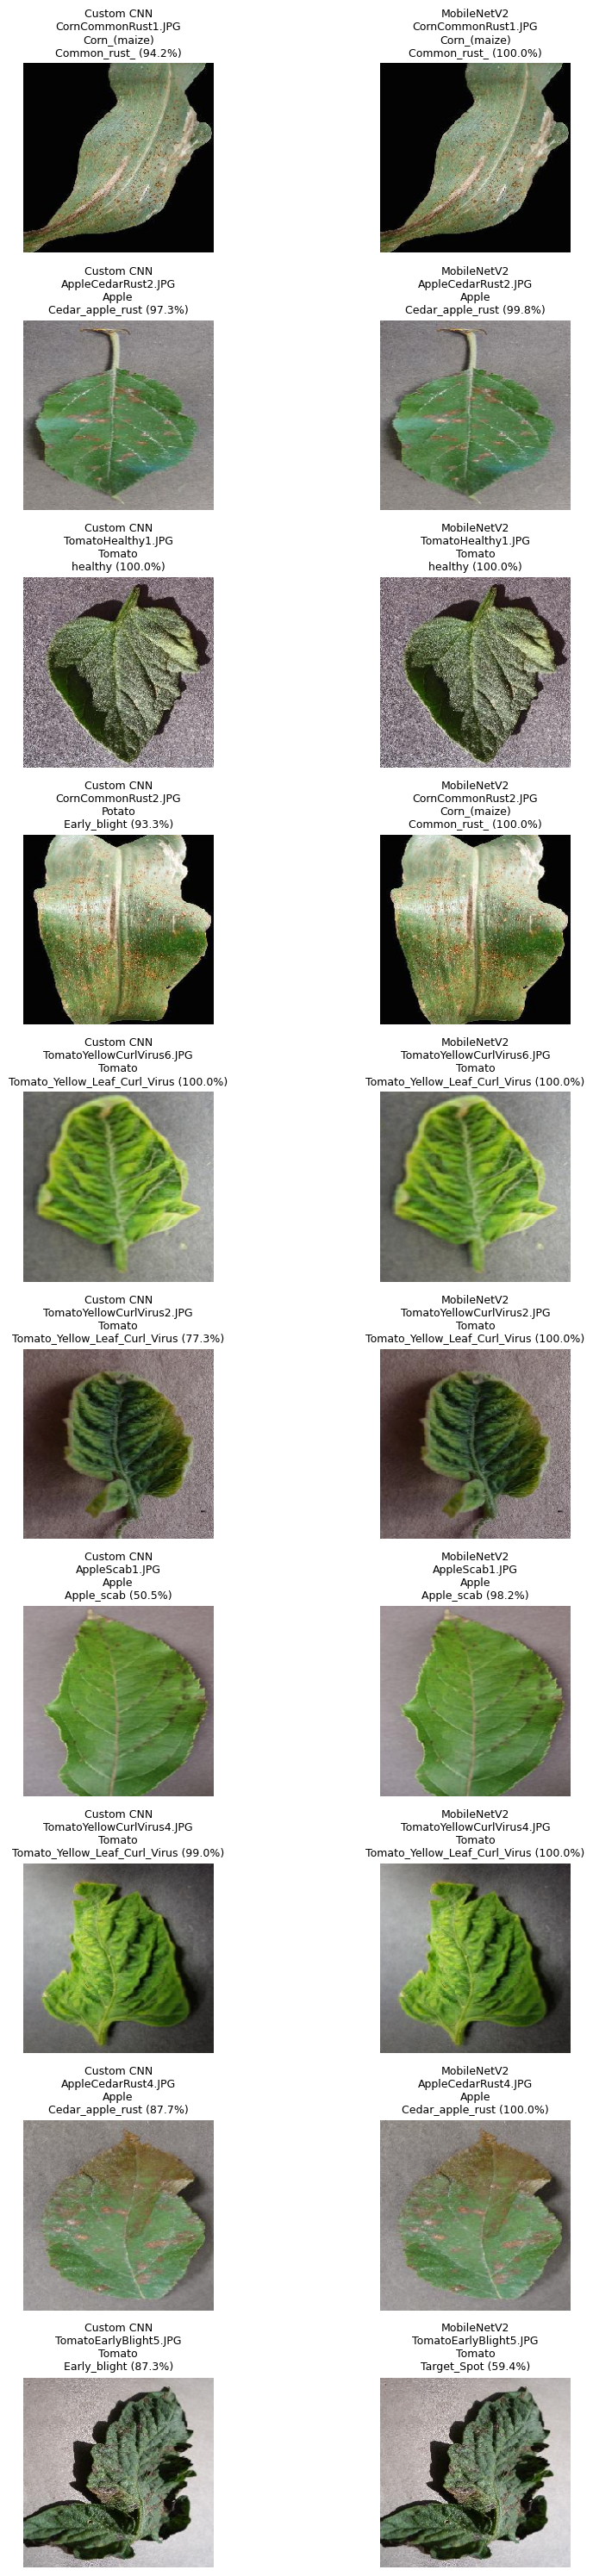

In [13]:
top1 = results[results['rank'] == 1].copy()
top1['label'] = top1['predicted_class'].str.replace('___', '\n', regex=False)

fig, axes = plt.subplots(IMAGE_COUNT, len(models), figsize=(10, 3 * IMAGE_COUNT))

if IMAGE_COUNT == 1:
    axes = np.expand_dims(axes, axis=0)

for row_index, image_path in enumerate(test_images):
    image = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    for col_index, model_name in enumerate(models):
        ax = axes[row_index, col_index]
        prediction = top1[(top1['image'] == image_path.name) & (top1['model'] == model_name)].iloc[0]
        ax.imshow(image)
        ax.set_title(
            f"{model_name}\n{image_path.name}\n{prediction['label']} ({prediction['confidence']:.1%})",
            fontsize=9,
        )
        ax.axis('off')

plt.tight_layout()

## Explain one prediction with SHAP

SHAP estimates which image regions pushed a model toward its prediction. For images, the masker hides or inpaints regions, the model is run on those perturbed images, and SHAP assigns contribution values to the visible regions. Positive regions support the selected class; negative regions push against it.

Use this section interactively for one image at a time. Image SHAP is approximate and can be slow, so start with a small `max_evals` value and increase it only if the heatmap is too noisy.

In [14]:
def get_named_model(model_name):
    if model_name not in models:
        available = ', '.join(models)
        raise ValueError(f'Unknown model_name={model_name!r}. Choose one of: {available}')
    return models[model_name]


def image_array_for_display(image_path):
    image = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    return tf.keras.utils.img_to_array(image).astype('float32')


def predict_batch(model, images):
    images = np.asarray(images, dtype='float32')
    return model.predict(images, verbose=0)


def explain_image_with_shap(model, image_path, max_evals=300, batch_size=20):
    image = image_array_for_display(image_path)
    image_batch = np.expand_dims(image, axis=0)

    probabilities = predict_batch(model, image_batch)[0]
    top_class_index = int(np.argmax(probabilities))
    top_class_name = class_names[top_class_index]
    top_confidence = float(probabilities[top_class_index])

    masker = shap.maskers.Image('inpaint_telea', image.shape)
    explainer = shap.Explainer(
        lambda masked_images: predict_batch(model, masked_images),
        masker,
        output_names=class_names,
    )
    shap_values = explainer(
        image_batch,
        max_evals=max_evals,
        batch_size=batch_size,
        outputs=[top_class_index],
    )

    return {
        'image': image,
        'probabilities': probabilities,
        'top_class_index': top_class_index,
        'top_class_name': top_class_name,
        'top_confidence': top_confidence,
        'shap_values': shap_values,
    }


def predict_and_explain_image(model_name, image_path, top_k=3, max_evals=300, batch_size=20):
    model = get_named_model(model_name)
    predictions = top_predictions(model, image_path, top_k=top_k)

    print(f'Image: {Path(image_path).name}')
    print(f'Model: {model_name}')
    print('Top predictions:')
    for prediction in predictions:
        print(f"  {prediction['rank']}. {prediction['class']}: {prediction['confidence']:.2%}")

    explanation = explain_image_with_shap(
        model=model,
        image_path=image_path,
        max_evals=max_evals,
        batch_size=batch_size,
    )

    plt.figure(figsize=(4, 4))
    plt.imshow(explanation['image'].astype('uint8'))
    plt.title(f"Original image: {Path(image_path).name}")
    plt.axis('off')
    plt.show()

    print(
        'Explaining top class: '
        f"{explanation['top_class_name']} ({explanation['top_confidence']:.2%})"
    )
    shap.image_plot(explanation['shap_values'], show=True)
    return explanation


Image: TomatoHealthy1.JPG
Model: Custom CNN
Top predictions:
  1. Tomato___healthy: 100.00%
  2. Potato___Early_blight: 0.00%
  3. Tomato___Late_blight: 0.00%


  0%|          | 0/298 [00:00<?, ?it/s]

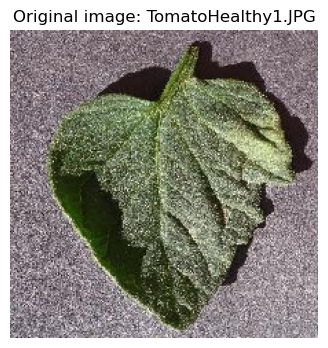

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..255.0].


Explaining top class: Tomato___healthy (100.00%)


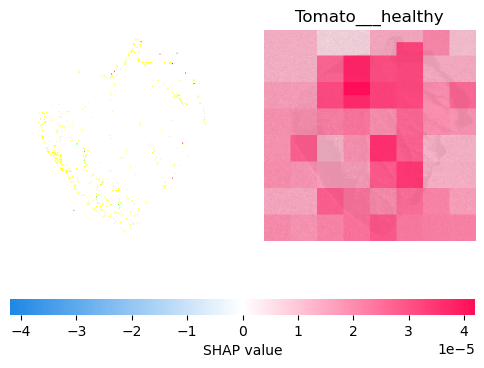

In [20]:
# Change these values to explain a different image or model.
sample_image_path = test_images[2]
model_name = 'Custom CNN'  # Choose 'MobileNetV2' or 'Custom CNN'.

explanation = predict_and_explain_image(
    model_name=model_name,
    image_path=sample_image_path,
    top_k=3,
    max_evals=300,
    batch_size=20,
)
